# 02 — Preprocessing Validation

**Project:** Robust Biometric Signature Verification Against Skilled Forgeries

Validates `sigver.data.preprocessing` on all five corpora before the
pipeline is frozen. Sections:

1. Step-by-step pipeline visualization (one sample per dataset)
2. Before/after grids — geometry sanity (esp. BHSig260 3.44 W/H padding)
3. Edge cases — CEDAR RGBA alpha handling, palette-mode TIFFs,
   blank-image error path
4. CEDAR brightness-shortcut test — does the genuine/forgery intensity
   gap survive preprocessing? (mean-ink-intensity-only EER)
5. Crop sanity — ink-coverage distribution, speck-inflated crops
6. Failure sweep + throughput — run the pipeline over a (sampled or
   full) corpus, log every failure, estimate full-corpus runtime

**Conventions**
- Writer identity = folder ID; raw data never modified.
- Figures -> `report/figures/preproc/`, tables -> `report/dataset_checks/`
  with `preproc_` prefix.
- `SWEEP_SAMPLE_PER_DATASET = None` for the full-corpus failure sweep
  (recommended once, before freezing); an int caps it for iteration.

In [ ]:
from __future__ import annotations

import random
import time
from pathlib import Path
from typing import Optional

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

from sigver.data.catalog import build_catalog
from sigver.data.preprocessing import (
    TARGET_HEIGHT,
    TARGET_WIDTH,
    otsu_threshold,
    preprocess_array,
    preprocess_image,
)
from sigver.evaluation.metrics import compute_eer

sns.set_theme(style="whitegrid", context="notebook")
RNG_SEED = 42
random.seed(RNG_SEED)
np.random.seed(RNG_SEED)

_here = Path.cwd()
PROJECT_ROOT = _here if (_here / "data" / "raw").is_dir() else _here.parent
assert (PROJECT_ROOT / "data" / "raw").is_dir(), (
    f"Could not locate data/raw relative to {_here}. "
    "Run from the project root or the notebooks/ folder."
)

RAW_ROOT = PROJECT_ROOT / "data" / "raw"
FIG_DIR = PROJECT_ROOT / "report" / "figures" / "preproc"
TABLE_DIR = PROJECT_ROOT / "report" / "dataset_checks"
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Failure sweep size. None = every image (long; run once before freezing).
SWEEP_SAMPLE_PER_DATASET: Optional[int] = None

print(f"Project root : {PROJECT_ROOT}")
print(f"Target size  : {TARGET_HEIGHT} x {TARGET_WIDTH} (H x W)")


def savefig(fig: plt.Figure, name: str) -> None:
    """Save a figure to report/figures/preproc/<name>.png at print quality."""
    out = FIG_DIR / f"{name}.png"
    fig.savefig(out, dpi=150, bbox_inches="tight")
    print(f"  saved -> {out.relative_to(PROJECT_ROOT)}")


catalog = build_catalog(RAW_ROOT)
df = catalog.dropna(subset=["label"]).copy()
print(f"Indexed {len(df):,} labeled files across {df['dataset'].nunique()} datasets")

## 1. Step-by-step pipeline visualization

For one random sample per dataset, show every intermediate stage:
original -> Otsu ink mask -> inverted (bg=0) -> tight crop -> final
padded+resized output. This is the figure that goes in the report's
preprocessing section.

  saved -> report\figures\preproc\pipeline_stages_bhsig260_bengali.png


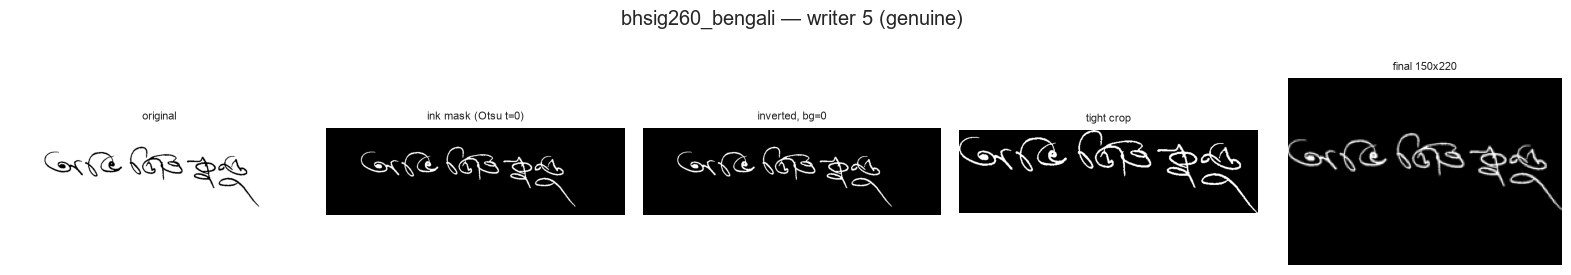

  saved -> report\figures\preproc\pipeline_stages_bhsig260_hindi.png


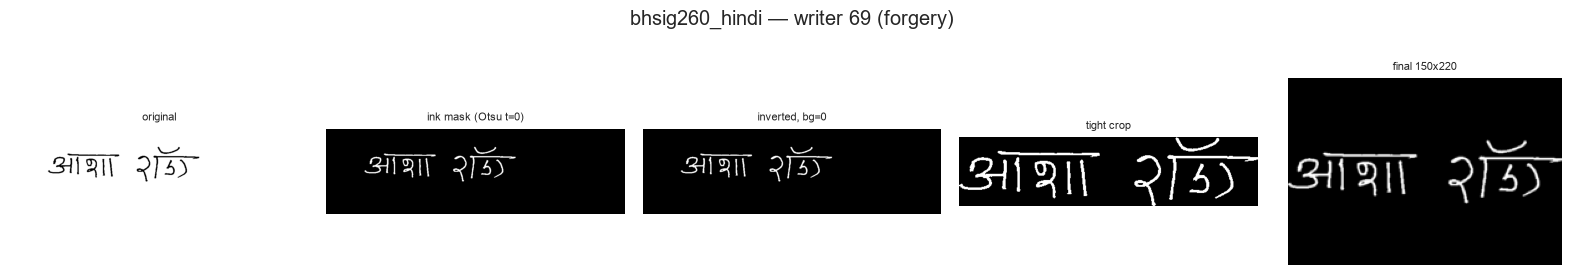

  saved -> report\figures\preproc\pipeline_stages_cedar.png


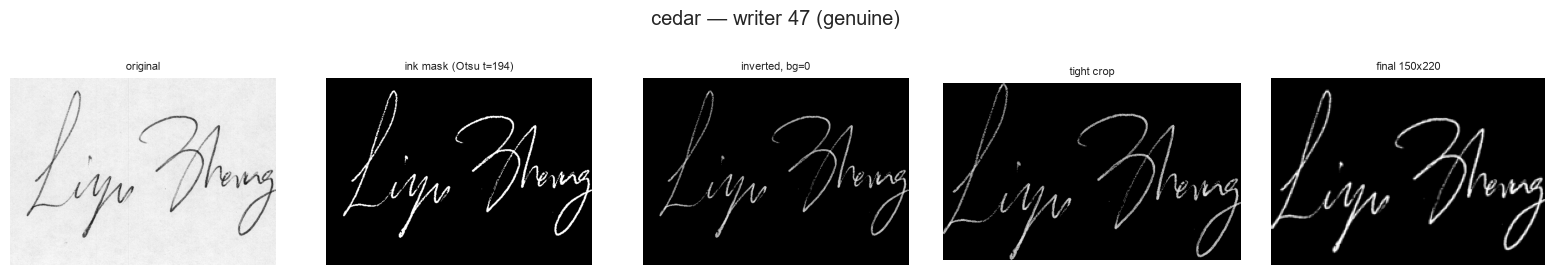

  saved -> report\figures\preproc\pipeline_stages_gpds_synthetic_4000.png


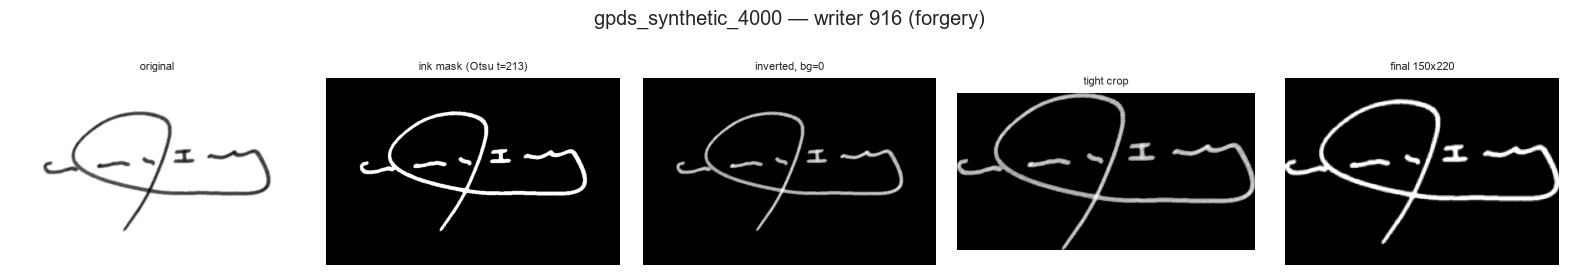

  saved -> report\figures\preproc\pipeline_stages_institutional.png


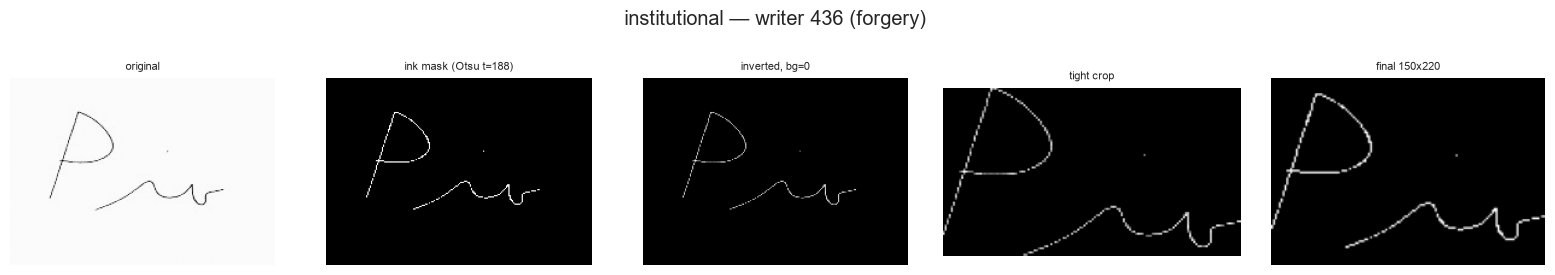

In [11]:
def load_gray_uint8(path: str) -> np.ndarray:
    """Load an image the same way preprocess_image does (PIL convert L)."""
    with Image.open(path) as img:
        return np.asarray(img.convert("L"), dtype=np.uint8)


def pipeline_stages(gray: np.ndarray) -> dict[str, np.ndarray]:
    """Recompute the intermediate stages of preprocess_array for display.

    Mirrors preprocessing.py steps 2-5. Kept in sync manually; if
    preprocessing.py changes, update this too (validation only).
    """
    t = otsu_threshold(gray)
    ink_mask = gray <= t

    inverted = 255 - gray.astype(np.int16)
    inverted[~ink_mask] = 0
    inverted = inverted.astype(np.uint8)

    rows = np.any(ink_mask, axis=1)
    cols = np.any(ink_mask, axis=0)
    r0, r1 = np.argmax(rows), len(rows) - np.argmax(rows[::-1])
    c0, c1 = np.argmax(cols), len(cols) - np.argmax(cols[::-1])
    cropped = inverted[r0:r1, c0:c1]

    final = preprocess_array(gray)
    return {
        "original": gray,
        f"ink mask (Otsu t={t})": ink_mask.astype(np.uint8) * 255,
        "inverted, bg=0": inverted,
        "tight crop": cropped,
        f"final {TARGET_HEIGHT}x{TARGET_WIDTH}": final,
    }


for ds, grp in df.groupby("dataset", observed=True):
    row = grp.sample(1, random_state=RNG_SEED).iloc[0]
    stages = pipeline_stages(load_gray_uint8(row["path"]))
    fig, axes = plt.subplots(1, len(stages), figsize=(3.2 * len(stages), 2.6))
    for ax, (name, img) in zip(axes, stages.items()):
        ax.imshow(img, cmap="gray")
        ax.set_title(name, fontsize=8)
        ax.axis("off")
    fig.suptitle(f"{ds} — writer {row['writer_id']} ({row['label']})", y=1.05)
    fig.tight_layout()
    savefig(fig, f"pipeline_stages_{ds}")
    plt.show()

## 2. Before/after grids

Random samples per dataset, raw vs. preprocessed. Things to eyeball:
- BHSig260 (W/H ~3.44): signatures become a horizontal band with large
  vertical padding — strokes must remain legible, not vanishingly thin.
- No clipped strokes at crop borders.
- Faint-pen signatures: ink must survive the Otsu mask (step 3 zeroes
  everything above threshold, so light strokes are at risk).

  saved -> report\figures\preproc\before_after_bhsig260_bengali.png


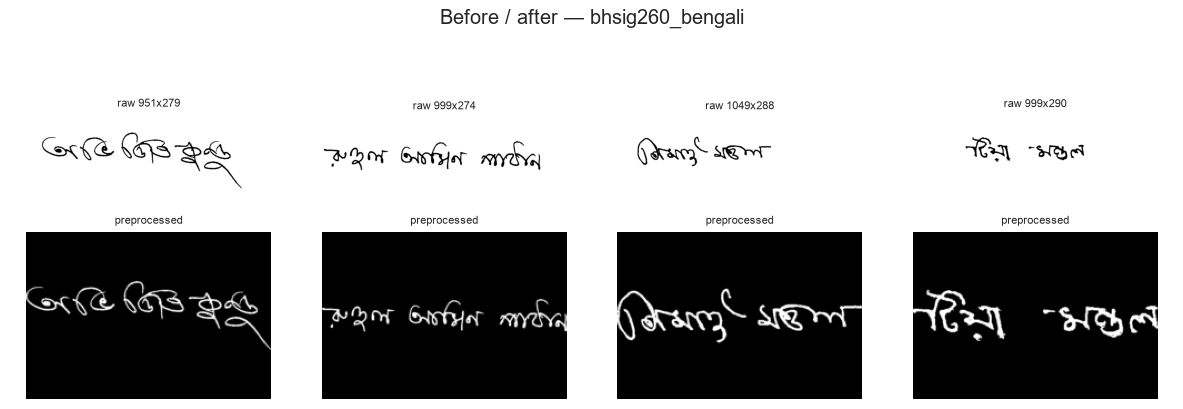

  saved -> report\figures\preproc\before_after_bhsig260_hindi.png


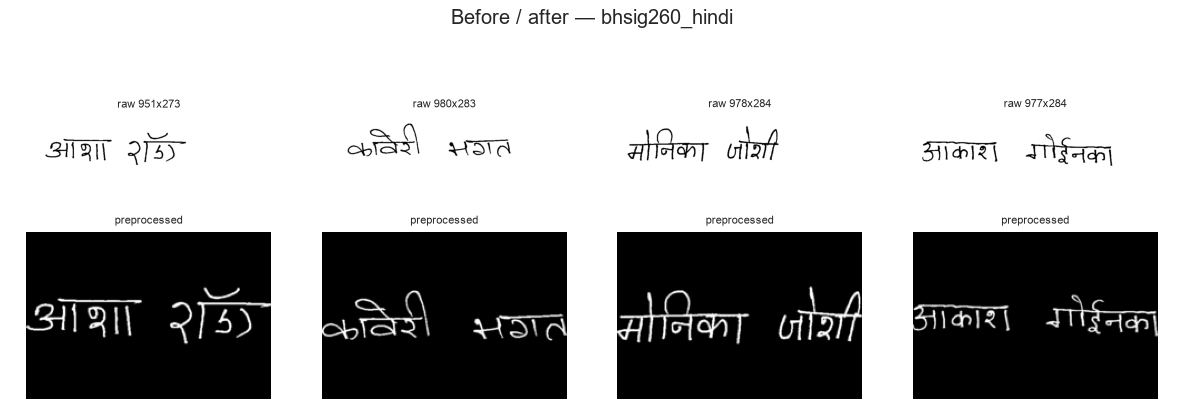

  saved -> report\figures\preproc\before_after_cedar.png


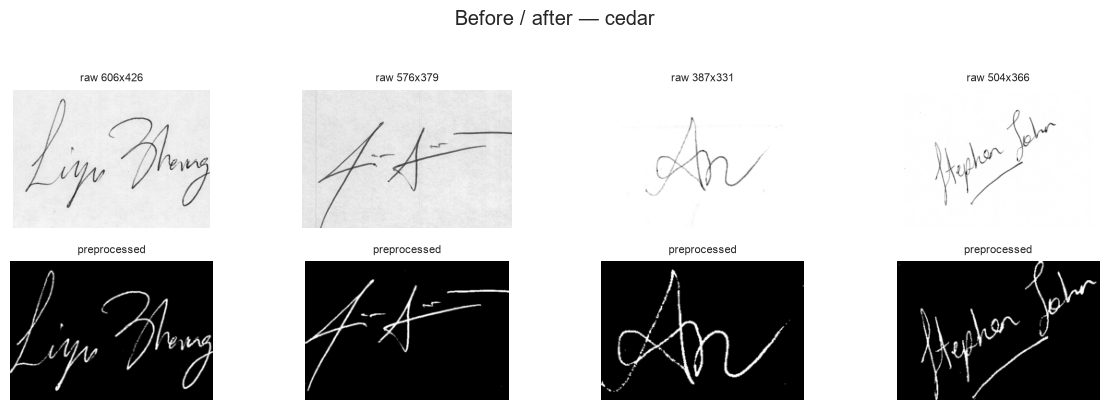

  saved -> report\figures\preproc\before_after_gpds_synthetic_4000.png


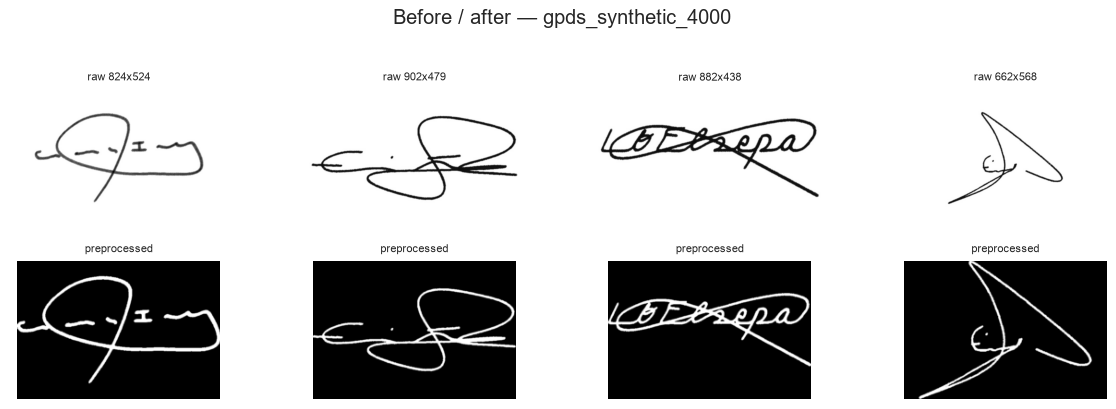

  saved -> report\figures\preproc\before_after_institutional.png


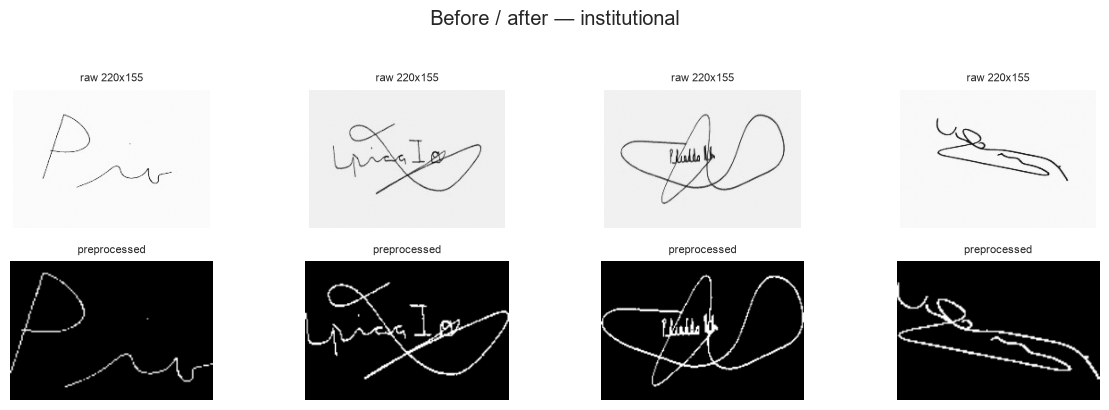

In [12]:
N_EXAMPLES = 4
for ds, grp in df.groupby("dataset", observed=True):
    sample = grp.sample(N_EXAMPLES, random_state=RNG_SEED)
    fig, axes = plt.subplots(2, N_EXAMPLES, figsize=(3.0 * N_EXAMPLES, 4.0))
    for col, (_, row) in enumerate(sample.iterrows()):
        gray = load_gray_uint8(row["path"])
        axes[0, col].imshow(gray, cmap="gray")
        axes[0, col].set_title(f"raw {gray.shape[1]}x{gray.shape[0]}", fontsize=8)
        try:
            out = preprocess_array(gray)
            axes[1, col].imshow(out, cmap="gray")
            axes[1, col].set_title("preprocessed", fontsize=8)
        except ValueError as e:
            axes[1, col].set_title(f"FAILED: {e}", fontsize=7, color="red")
        for r in (0, 1):
            axes[r, col].axis("off")
    fig.suptitle(f"Before / after — {ds}", y=1.02)
    fig.tight_layout()
    savefig(fig, f"before_after_{ds}")
    plt.show()

## 3. Edge cases

### 3a. CEDAR RGBA alpha handling

`Image.convert("L")` on RGBA **drops alpha without compositing**. If any
of the 144 CEDAR RGBA files use transparency for the background, it
turns black -> Otsu treats the whole background as ink -> broken output.
Test: for every RGBA file, compare plain `convert("L")` against an
explicit white-composite; any pixel difference means alpha matters.

In [13]:
rgba_rows = []
cedar_paths = df.loc[df["dataset"] == "cedar", "path"]
for p in cedar_paths:
    with Image.open(p) as img:
        if img.mode != "RGBA":
            continue
        plain = np.asarray(img.convert("L"), dtype=np.int16)
        white = Image.new("RGBA", img.size, (255, 255, 255, 255))
        composited = np.asarray(
            Image.alpha_composite(white, img).convert("L"), dtype=np.int16
        )
        alpha = np.asarray(img.getchannel("A"))
        rgba_rows.append({
            "path": p,
            "alpha_min": int(alpha.min()),
            "n_transparent_px": int((alpha < 255).sum()),
            "max_abs_diff_vs_composite": int(np.abs(plain - composited).max()),
        })

rgba_report = pd.DataFrame(rgba_rows)
if rgba_report.empty:
    print("No RGBA files found in CEDAR (unexpected — EDA counted 144).")
else:
    n_affected = int((rgba_report["max_abs_diff_vs_composite"] > 0).sum())
    print(f"RGBA files checked: {len(rgba_report)}")
    print(f"Files where dropping alpha changes pixels: {n_affected}")
    rgba_report.to_csv(TABLE_DIR / "preproc_cedar_rgba_check.csv", index=False)
    if n_affected > 0:
        print("WARNING: convert('L') is NOT safe for these files — "
              "preprocessing.py must composite RGBA onto white first.")
        print(rgba_report[rgba_report["max_abs_diff_vs_composite"] > 0]
              .head(10).to_string(index=False))
    else:
        print("All alpha channels are fully opaque -> convert('L') is safe.")

RGBA files checked: 144
Files where dropping alpha changes pixels: 0
All alpha channels are fully opaque -> convert('L') is safe.


### 3b. Palette-mode TIFFs (BHSig260)

01_eda read images with `cv2.IMREAD_GRAYSCALE`; preprocessing uses PIL
`convert("L")`. The two use different RGB->gray weights and palette
handling, so verify they agree closely on P-mode files — otherwise the
EDA intensity conclusions would not transfer to the training pipeline.

In [14]:
import cv2  # noqa: E402  (only needed for this cross-check)

p_mode = []
for ds in ("bhsig260_bengali", "bhsig260_hindi"):
    sub = df[df["dataset"] == ds].sample(200, random_state=RNG_SEED)
    for p in sub["path"]:
        with Image.open(p) as img:
            if img.mode != "P":
                continue
            pil_gray = np.asarray(img.convert("L"), dtype=np.int16)
        cv_gray = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
        if cv_gray is None or cv_gray.shape != pil_gray.shape:
            p_mode.append({"dataset": ds, "path": p, "max_abs_diff": -1})
            continue
        p_mode.append({
            "dataset": ds, "path": p,
            "max_abs_diff": int(np.abs(pil_gray - cv_gray.astype(np.int16)).max()),
        })

pmode_report = pd.DataFrame(p_mode)
if pmode_report.empty:
    print("No P-mode files in the sampled subset.")
else:
    print(pmode_report.groupby("dataset")["max_abs_diff"]
          .agg(["count", "max", "mean"]).round(2))
    pmode_report.to_csv(TABLE_DIR / "preproc_pmode_pil_vs_cv2.csv", index=False)
    # Small differences (a few gray levels, from rounding/weights) are fine;
    # large ones (>20) or shape mismatches (-1) need investigation.

                  count  max  mean
dataset                           
bhsig260_bengali     39    0   0.0
bhsig260_hindi       99    0   0.0


### 3c. Blank-image error path

In [15]:
blank = np.full((100, 200), 255, dtype=np.uint8)
try:
    preprocess_array(blank)
    print("PROBLEM: blank image did not raise — silent-failure risk.")
except ValueError as e:
    print(f"OK: blank image raises ValueError ('{e}')")

OK: blank image raises ValueError ('no ink found after Otsu thresholding (blank image?)')


## 4. CEDAR brightness-shortcut test

01_eda found a genuine-vs-forgery mean-intensity gap in the raw CEDAR
scans (acquisition artifact). Step 3 keeps ink in **grayscale**, so the
gap can survive into the model inputs. Test on *preprocessed* images:

1. Compare mean nonzero (ink) intensity per class.
2. Compute EER using mean ink intensity **alone** as the match score
   for genuine-vs-skilled-forgery discrimination per writer.

If (2) is meaningfully below 50%, the network can exploit brightness
instead of shape -> add per-image ink normalization (or binarize)
before freezing.

In [ ]:
import cv2  # noqa: E402  (connected-components check below)

ced = df[df["dataset"] == "cedar"]
parts = [
    g.sample(min(len(g), 2000), random_state=RNG_SEED)
    for _, g in ced.groupby("label", observed=True)
]  # pandas 3.0: groupby().apply() excludes the grouping column from g,
   # so a plain loop is used here to keep 'label' in per_class.
per_class = pd.concat(parts).reset_index(drop=True)

# Single pass over the CEDAR sample: preprocessed ink stats, connected
# components, and the raw-vs-preprocessed intensity pair used by the
# attribution check below, all from one preprocess_image() call per row.
records = []
raw_vs_preproc = []
for _, row in per_class.iterrows():
    try:
        out = preprocess_image(row["path"])
    except ValueError:
        continue
    ink = out[out > 0]
    n_components, _ = cv2.connectedComponents((out > 0.5).astype(np.uint8))
    with Image.open(row["path"]) as img:
        g = np.asarray(img.convert("L"), dtype=np.uint8)
    t = otsu_threshold(g)
    ink_px = g[g <= t]
    records.append({
        "label": row["label"],
        "writer_id": row["writer_id"],
        "mean_ink_intensity": float(ink.mean()),
        "ink_fraction": float((out > 0).mean()),
        "n_components": n_components - 1,  # minus background
    })
    if ink_px.size:
        raw_vs_preproc.append((float(ink_px.mean()), float(ink.mean())))
ink_stats = pd.DataFrame(records)

print(ink_stats.groupby("label")[["mean_ink_intensity", "ink_fraction", "n_components"]]
      .describe().round(4).T)

fig, ax = plt.subplots(figsize=(6, 4))
sns.kdeplot(data=ink_stats, x="mean_ink_intensity", hue="label",
            common_norm=False, fill=True,
            palette={"genuine": "#2a9d8f", "forgery": "#e76f51"}, ax=ax)
ax.set_title("CEDAR preprocessed: mean ink intensity by class")
savefig(fig, "cedar_ink_intensity_by_class")
plt.show()


# Intensity-only EER (and the same test for ink_fraction / n_components):
# score = |difference| in a stat between a genuine reference and a
# questioned signature of the same writer. Positive pairs: genuine-genuine
# (same writer). Negative pairs: genuine-forgery. EER comes from
# sigver.evaluation.metrics.compute_eer (accept iff score <= threshold,
# same "small score wins" convention as its distance metric) instead of a
# hand-rolled sweep — the old sweep silently returned its 0.5
# initialization ("pass") whenever no threshold landed within the 0.01
# FAR/FRR tolerance, and biased low by taking min() over every threshold
# that did.
def build_score_pairs(stats: pd.DataFrame, col: str, n_pairs: int = 4000,
                      seed: int = RNG_SEED) -> tuple[np.ndarray, np.ndarray]:
    rng = np.random.default_rng(seed)
    by_writer_lbl = {
        k: g[col].to_numpy()
        for k, g in stats.groupby(["writer_id", "label"], observed=True)
    }
    writers = sorted({w for (w, _) in by_writer_lbl})
    scores, labels = [], []
    for _ in range(n_pairs):
        w = writers[rng.integers(len(writers))]
        gen = by_writer_lbl.get((w, "genuine"))
        forg = by_writer_lbl.get((w, "forgery"))
        if gen is None or len(gen) < 2 or forg is None:
            continue
        # positive pair
        i, j = rng.choice(len(gen), 2, replace=False)
        scores.append(abs(gen[i] - gen[j])); labels.append(1)
        # negative pair
        scores.append(abs(gen[rng.integers(len(gen))]
                          - forg[rng.integers(len(forg))])); labels.append(0)
    return np.asarray(scores), np.asarray(labels)


def stat_eer(stats: pd.DataFrame, col: str) -> float:
    """EER (via compute_eer) using an arbitrary column as the score."""
    scores, labels = build_score_pairs(stats, col)
    eer, _ = compute_eer(scores, labels)
    return eer


eer_by_stat = {col: stat_eer(ink_stats, col) for col in
              ["mean_ink_intensity", "ink_fraction", "n_components"]}
eer_intensity = eer_by_stat["mean_ink_intensity"]

print(f"\nIntensity-only EER (CEDAR, genuine vs skilled forgery): "
      f"{eer_intensity:.4f}")
print("~0.5 => brightness carries no signal (good). Meaningfully below "
      "0.5 => shortcut survives preprocessing; consider per-image ink "
      "normalization or binarization before freezing.")

PRIOR_RECORDED_EER = 0.3549  # from the earlier hand-rolled sweep
drift = abs(eer_intensity - PRIOR_RECORDED_EER)
flag = " [FLAG: drift > 0.02]" if drift > 0.02 else " [consistent]"
print(f"Prior recorded value: {PRIOR_RECORDED_EER:.4f} | "
      f"drift: {drift:.4f}{flag}")


# Fragmentation check: connected components in the final binary output.
# High component counts relative to genuine strokes can flag speckle/noise
# that a model could also learn to exploit as a shortcut.
for col, eer in eer_by_stat.items():
    print(f"{col:22s} EER {eer:.4f} | "
          f"forgery {ink_stats[ink_stats.label=='forgery'][col].mean():.3f} "
          f"genuine {ink_stats[ink_stats.label=='genuine'][col].mean():.3f}")


# Attribution check: does raw ink darkness predict preprocessed
# stroke width (mean intensity of the binary output)?
a = np.asarray(raw_vs_preproc)
r = np.corrcoef(a[:, 0], a[:, 1])[0, 1]
print(f"\ncorr(raw ink darkness, preprocessed mean intensity): {r:.3f}  "
      f"(n={len(a)})")
print("r strongly negative (<= -0.4): darker raw ink -> thicker mask; "
      "width gap attributable to acquisition artifact, augmentation is the "
      "mitigation. |r| small (<= 0.2): width difference is independent of "
      "ink darkness -> likely genuine behavioral signal. In between: "
      "partial attribution.")

pd.DataFrame([{
    "intensity_only_eer": eer_by_stat["mean_ink_intensity"],
    "ink_fraction_eer": eer_by_stat["ink_fraction"],
    "n_components_eer": eer_by_stat["n_components"],
    "corr_raw_vs_preproc_intensity": float(r),
    "corr_n": len(a),
    "n_images": len(ink_stats),
}]).to_csv(TABLE_DIR / "preproc_cedar_shortcut_eer.csv", index=False)


## 5. Crop sanity

Ink fraction of the final output per dataset. Outliers flag problems:
- near-zero ink fraction -> speck/noise inflated the crop box, the
  signature shrank to a few pixels;
- very high ink fraction -> background misclassified as ink.

  saved -> report\figures\preproc\ink_fraction_per_dataset.png


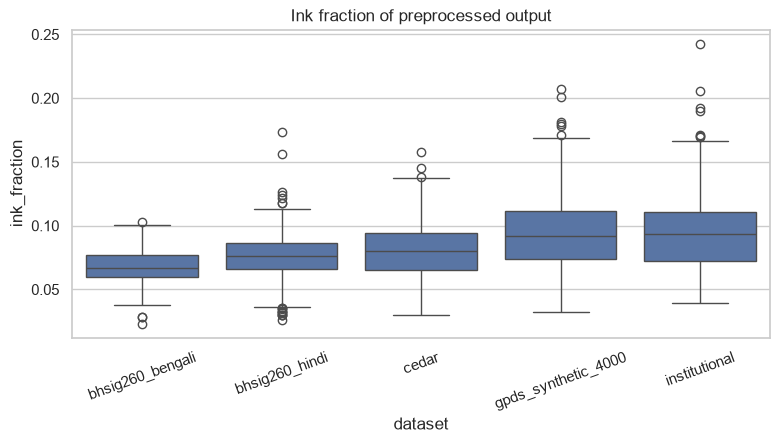

Suspicious outputs: 0 near-empty (<0.5% ink), 0 over-inked (>50%).


In [17]:
crop_records = []
for ds, grp in df.groupby("dataset", observed=True):
    sub = grp.sample(min(len(grp), 300), random_state=RNG_SEED)
    for _, row in sub.iterrows():
        try:
            out = preprocess_image(row["path"])
            crop_records.append({"dataset": ds, "path": row["path"],
                                 "ink_fraction": float((out > 0).mean())})
        except ValueError as e:
            crop_records.append({"dataset": ds, "path": row["path"],
                                 "ink_fraction": np.nan})
crop_df = pd.DataFrame(crop_records)

fig, ax = plt.subplots(figsize=(9, 4))
sns.boxplot(data=crop_df, x="dataset", y="ink_fraction", ax=ax)
ax.set_title("Ink fraction of preprocessed output")
ax.tick_params(axis="x", rotation=20)
savefig(fig, "ink_fraction_per_dataset")
plt.show()

low = crop_df[crop_df["ink_fraction"] < 0.005]
high = crop_df[crop_df["ink_fraction"] > 0.5]
print(f"Suspicious outputs: {len(low)} near-empty (<0.5% ink), "
      f"{len(high)} over-inked (>50%).")
outliers = pd.concat([low, high])
if not outliers.empty:
    outliers.to_csv(TABLE_DIR / "preproc_crop_outliers.csv", index=False)
    # Visualize the worst few for manual inspection.
    worst = outliers.head(6)
    fig, axes = plt.subplots(2, len(worst), figsize=(2.6 * len(worst), 4.0))
    axes = np.atleast_2d(axes)
    for col, (_, row) in enumerate(worst.iterrows()):
        gray = load_gray_uint8(row["path"])
        axes[0, col].imshow(gray, cmap="gray")
        try:
            axes[1, col].imshow(preprocess_array(gray), cmap="gray")
        except ValueError:
            pass
        for r in (0, 1):
            axes[r, col].axis("off")
        axes[0, col].set_title(f"{row['ink_fraction']:.4f}", fontsize=8)
    fig.suptitle("Crop outliers: raw (top) vs preprocessed (bottom)", y=1.02)
    savefig(fig, "crop_outliers")
    plt.show()

## 6. Failure sweep + throughput

Run the full pipeline over the corpus (sampled or full, see
`SWEEP_SAMPLE_PER_DATASET`), log every exception, and estimate the
full-corpus runtime. Set the cap to `None` and run overnight once —
that result is the freeze gate.

In [18]:
def sample_paths(frame: pd.DataFrame, per_dataset: Optional[int]) -> pd.DataFrame:
    if per_dataset is None:
        return frame
    parts = [g.sample(min(len(g), per_dataset), random_state=RNG_SEED)
             for _, g in frame.groupby("dataset", observed=True)]
    return pd.concat(parts)


sweep = sample_paths(df, SWEEP_SAMPLE_PER_DATASET)
print(f"Sweeping {len(sweep):,} images "
      f"(cap per dataset: {SWEEP_SAMPLE_PER_DATASET})")

failures = []
timings: dict[str, list[float]] = {}
for ds, grp in sweep.groupby("dataset", observed=True):
    t_ds = []
    for _, row in grp.iterrows():
        t0 = time.perf_counter()
        try:
            preprocess_image(row["path"])
        except Exception as e:  # log everything, not just ValueError
            failures.append({"dataset": ds, "path": row["path"],
                             "error": f"{type(e).__name__}: {e}"})
        t_ds.append(time.perf_counter() - t0)
    timings[ds] = t_ds
    total_ds = int((df["dataset"] == ds).sum())
    med_ms = float(np.median(t_ds) * 1000)
    est_min = total_ds * float(np.mean(t_ds)) / 60
    print(f"  {ds:22s} median {med_ms:6.1f} ms/img -> "
          f"full dataset est. {est_min:6.1f} min")

fail_df = pd.DataFrame(failures)
summary = pd.DataFrame([{
    "n_swept": len(sweep),
    "sample_cap": SWEEP_SAMPLE_PER_DATASET,
    "n_failures": len(fail_df),
    "date": pd.Timestamp.now().isoformat(timespec="seconds"),
}])
summary.to_csv(TABLE_DIR / "preproc_sweep_summary.csv", index=False)
# Always write the failures file (possibly empty) — provable absence.
fail_df.to_csv(TABLE_DIR / "preproc_failures.csv", index=False)
print(f"\nFailures: {len(fail_df)}")
if not fail_df.empty:
    print(fail_df.groupby("dataset").size().to_string())

Sweeping 344,680 images (cap per dataset: None)
  bhsig260_bengali       median   18.4 ms/img -> full dataset est.    1.6 min
  bhsig260_hindi         median   19.3 ms/img -> full dataset est.    2.9 min
  cedar                  median    6.2 ms/img -> full dataset est.    0.3 min
  gpds_synthetic_4000    median    8.9 ms/img -> full dataset est.   35.5 min
  institutional          median    2.4 ms/img -> full dataset est.    5.1 min

Failures: 0


## Validation takeaways checklist

- [ ] Pipeline stages look correct on all five datasets (Section 1)
- [ ] BHSig260 padding keeps strokes legible; no border clipping (S2)
- [ ] CEDAR RGBA: alpha fully opaque OR preprocessing composites onto
      white (S3a — `preproc_cedar_rgba_check.csv`)
- [ ] PIL vs cv2 grayscale agree on palette TIFFs (S3b)
- [ ] Blank images raise ValueError (S3c)
- [ ] Intensity-only EER ~0.5 on CEDAR — brightness shortcut neutralized
      (S4 — `preproc_cedar_shortcut_eer.csv`)
- [ ] No unexplained crop outliers (S5 — `preproc_crop_outliers.csv`)
- [ ] Full-corpus sweep (`SWEEP_SAMPLE_PER_DATASET = None`): zero
      unexplained failures (S6 — `preproc_failures.csv`)

All boxes ticked -> preprocessing is FROZEN. Record the freeze date and
git commit hash in the report.